## Experimental notebook

used for testing and bug fixing! sorry it won't be pretty :(

In [87]:
import sys
import os
sys.path.append(os.path.abspath(".."))
from datetime import date
from src.data import download_stock_data, clean_stock_data
from src.simulation import montecarlo_iteration
from src.evaluation import forecast_dispersion_width,jump_comparison,maximum_absolute_percentage_error, rolling_root_mean_squared_error, root_mean_squared_error, mean_absolute_percentage_error, prediction_interval_coverage
from src.visualization import histogram, plot_results


#### Stock name list

Useful Stock / ETF Tickers for Testing

High Volatility / Tech
TSLA  - Tesla
NVDA  - Nvidia
AMD   - AMD
META  - Meta
NFLX  - Netflix
AMZN  - Amazon
GOOGL - Google
MSFT  - Microsoft
AAPL  - Apple

Stable / Defensive Stocks
KO    - Coca-Cola
PEP   - Pepsi
JNJ   - Johnson & Johnson
PG    - Procter & Gamble
WMT   - Walmart
MCD   - McDonald's
COST  - Costco

Financials
JPM   - JPMorgan
BAC   - Bank of America
GS    - Goldman Sachs
V     - Visa
MA    - Mastercard

ETFs (Excellent for Calibration)
SPY   - S&P 500 ETF
QQQ   - Nasdaq ETF
DIA   - Dow Jones ETF
IWM   - Russell 2000 ETF

Market Indices (Yahoo Finance style)
^GSPC - S&P 500 Index
^IXIC - Nasdaq Composite
^DJI  - Dow Jones Index

#### Actual code starts

In [88]:
#defing all the parameters needed for the simulation and analysis

stock_name = "MCD"
training_start_date = date(2013,1,1) # year, month, day
evaluation_start_date = date(2023,1,1) # year, month, day
evaluation_end_date = date(2026,1,1) # year, month, day
montecarlo_days = int(700)
montecarlo_iterations = int(40)

In [89]:
#Downloading and cleaning all the data needed including evaluation data!

training_data = download_stock_data(stock_name, training_start_date, evaluation_start_date)
evaluation_data = download_stock_data(stock_name, evaluation_start_date, evaluation_end_date)

clean_training_data = clean_stock_data(training_data)

clean_evaluation_data = clean_stock_data(evaluation_data)

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [90]:
#running the montecarlo simulation.

montecarlo_simulations = montecarlo_iteration(clean_training_data, bin_width=0.1/100, sigma_multiplier=2.5, days=montecarlo_days, iterations=montecarlo_iterations, allow_jumps=True)    

#### Plotting the data

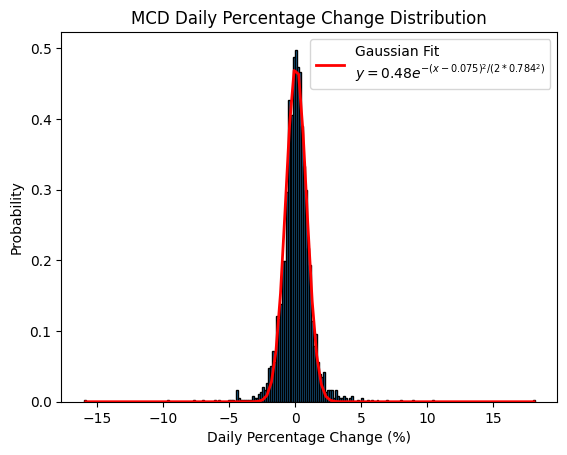

In [91]:
#First a histogram to see if the gaussian assumption used is valid for the percentage change distribution. We can also see if there are any jumps in the data and how they are distributed.
clean_training_data["pct_change"] = clean_training_data["Close"].pct_change()
histogram(clean_training_data["pct_change"].dropna()*100, bin_width=0.15, gaussian_fit=True, title=f"{stock_name} Daily Percentage Change Distribution", xlabel="Daily Percentage Change (%)", ylabel="Probability", show_graph=True, save_graph=False)


In [92]:
#next the complete and hopefully interactive graph comparing the monte carlo simulations with the actual data and the training data.

fig = plot_results(
    simulations=montecarlo_simulations,
    confidence_level=0.95,
    sd_multiplier=1.3,
    stock_name=stock_name,
    historical_data=clean_training_data["Close"],
    historical_plot_days=252,
    actual_data=clean_evaluation_data["Close"].iloc[0:montecarlo_days],
    allow_jumps=True,
    show_paths=True,
    show_mean=True,
    show_median=True,
    show_prediction_interval=True,
    show_sd_band=True,
    show_mean_confidence_interval=True,
    show_actual=True,
    max_paths=10
)

fig.show()

#### Evaluating the results

In [93]:
#some evaluation parameters
confidence_level = 0.95
window_size = 20

In [94]:
# 1. Prediction Interval Coverage
coverage = prediction_interval_coverage(
    simulations=montecarlo_simulations,
    actual_data=clean_evaluation_data["Close"],
    confidence_level=confidence_level
)

print("\nPrediction Interval Coverage:")
print(f"{coverage:.2f}%")


Prediction Interval Coverage:
76.86%


In [95]:
# 2. Mean Absolute Percentage Error (MEAN)


mape_mean = mean_absolute_percentage_error(
    simulations=montecarlo_simulations,
    actual_data=clean_evaluation_data["Close"],
    use_median=False
)
print("\nMAPE (Mean Forecast):")
print(f"{mape_mean:.2f}%")

# and with the MEDIAN

mape_median = mean_absolute_percentage_error(
    simulations=montecarlo_simulations,
    actual_data=clean_evaluation_data["Close"],
    use_median=True
)

print("\nMAPE (Median Forecast):")
print(f"{mape_median:.2f}%")


MAPE (Mean Forecast):
26.27%

MAPE (Median Forecast):
24.41%


In [96]:
# 3. Root Mean Squared Error (MEAN)

rmse_mean = root_mean_squared_error(
    simulations=montecarlo_simulations,
    actual_data=clean_evaluation_data["Close"],
    use_median=False
)

print("\nRMSE (Mean Forecast):")
print(f"{rmse_mean:.4f}")

# and for the median

rmse_median = root_mean_squared_error(
    simulations=montecarlo_simulations,
    actual_data=clean_evaluation_data["Close"],
    use_median=True
)

print("\nRMSE (Median Forecast):")
print(f"{rmse_median:.4f}")



RMSE (Mean Forecast):
94.1726

RMSE (Median Forecast):
89.5553


In [97]:
# 4. Rolling RMSE (MEAN)

rolling_rmse = rolling_root_mean_squared_error(
    simulations=montecarlo_simulations,
    actual_data=clean_evaluation_data["Close"],
    use_median=False,
    window_size=window_size
)

print("\nRolling RMSE mean:")
print(rolling_rmse[:10])

#and median

rolling_rmse = rolling_root_mean_squared_error(
    simulations=montecarlo_simulations,
    actual_data=clean_evaluation_data["Close"],
    use_median=True,
    window_size=window_size
)

print("\nRolling RMSE median:")
print(rolling_rmse[:10])


Rolling RMSE mean:
[3.9928393  3.99113422 4.08645235 4.15527095 3.99181427 3.95067917
 4.05847259 4.34152416 4.52918909 4.4849352 ]

Rolling RMSE median:
[3.78707997 3.78390764 3.85697281 3.8656219  3.73410351 3.69306177
 3.76979822 4.05185479 4.31694852 4.31008254]


In [98]:
# 5. Maximum Absolute Percentage Error (MEAN)

max_ape = maximum_absolute_percentage_error(
    simulations=montecarlo_simulations,
    actual_data=clean_evaluation_data["Close"],
    use_median=False
)

print("\nMaximum Absolute Percentage Error mean:")
print(f"{max_ape:.2f}%")

#and median

max_ape = maximum_absolute_percentage_error(
    simulations=montecarlo_simulations,
    actual_data=clean_evaluation_data["Close"],
    use_median=True
)

print("\nMaximum Absolute Percentage Error median:")
print(f"{max_ape:.2f}%")


Maximum Absolute Percentage Error mean:
68.76%

Maximum Absolute Percentage Error median:
72.64%


In [99]:
# 6. Forecast Dispersion Width

dispersion_width = forecast_dispersion_width(
    simulations=montecarlo_simulations,
    confidence_level=confidence_level
)

print("\nForecast Dispersion Width:")
print(dispersion_width[:10])




# and based on this the average Forecast Dispersion Growth Rate
from src.evaluation import average_forecast_dispersion_growth_rate

dispersion_growth_rate = (
    average_forecast_dispersion_growth_rate(
        simulations=montecarlo_simulations,
        confidence_level=confidence_level
    )
)

print("\nAverage Forecast Dispersion Growth Rate:")
print(f"{dispersion_growth_rate:.6f}")


Forecast Dispersion Width:
[ 0.          7.06955892 10.98284809 15.72657165 19.37562276 21.73606748
 25.61457955 26.29197138 28.87705226 29.99851747]

Average Forecast Dispersion Growth Rate:
0.556956


In [100]:
# 7. Jump Comparison

jump_stats = jump_comparison(
    simulations=montecarlo_simulations,
    actual_data=clean_evaluation_data,
    training_data=clean_training_data,
    jump_threshold_multiplier=2.5
)

print("\nJump Comparison:")
print(jump_stats)



# Pretty Jump Output :)

print("\n--- REAL DATA JUMPS ---")

print(
    f"Positive Jump Count: "
    f"{jump_stats['real_data']['positive_jump_count']}"
)

print(
    f"Negative Jump Count: "
    f"{jump_stats['real_data']['negative_jump_count']}"
)

print(
    f"Average Positive Jump: "
    f"{jump_stats['real_data']['average_positive_jump']:.4f}"
)

print(
    f"Average Negative Jump: "
    f"{jump_stats['real_data']['average_negative_jump']:.4f}"
)


print("\n--- SIMULATION JUMPS ---")

print(
    f"Average Positive Jump Count: "
    f"{jump_stats['simulation_data']['average_positive_jump_count']:.2f}"
)

print(
    f"Average Negative Jump Count: "
    f"{jump_stats['simulation_data']['average_negative_jump_count']:.2f}"
)

print(
    f"Average Positive Jump: "
    f"{jump_stats['simulation_data']['average_positive_jump']:.4f}"
)

print(
    f"Average Negative Jump: "
    f"{jump_stats['simulation_data']['average_negative_jump']:.4f}"
)



Jump Comparison:
{'real_data': {'positive_jump_count': 5, 'negative_jump_count': 5, 'average_positive_jump': np.float64(0.03732673171386862), 'average_negative_jump': np.float64(-0.04351069901244302)}, 'simulation_data': {'average_positive_jump_count': np.float64(8.6), 'average_negative_jump_count': np.float64(7.175), 'average_positive_jump': np.float64(0.0568157970139327), 'average_negative_jump': np.float64(-0.053478357147119)}}

--- REAL DATA JUMPS ---
Positive Jump Count: 5
Negative Jump Count: 5
Average Positive Jump: 0.0373
Average Negative Jump: -0.0435

--- SIMULATION JUMPS ---
Average Positive Jump Count: 8.60
Average Negative Jump Count: 7.17
Average Positive Jump: 0.0568
Average Negative Jump: -0.0535
